In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss

# 2. EDA

In [2]:
#read polymarket data
import sys
import os
import polars as pl
#from pathlib import path

sys.path.append(os.path.abspath('..'))
# Import the loader from the template provided by the project
from eda_starter_template import load_polymarket_data, POLYMARKET_DIR

# Load the dictionary of DataFrames
poly_data_dict = load_polymarket_data(POLYMARKET_DIR)

# Extract individual DataFrames for easier use
if poly_data_dict:
    df_markets = poly_data_dict.get("markets")
    df_odds = poly_data_dict.get("odds")
    df_summary = poly_data_dict.get("summary")
    
    print("Data loaded successfully!")
else:
    print("Data directory not found. Check if the 'data/Polymarket' folder exists.")

Loading Polymarket data from D:\7406Poly\polymarket-analysis-team66-omsa\data\Polymarket...
[Memory] Before loading Polymarket data: 229.10 MB
Loaded 78321 markets.
Loaded 2143181 odds history records.
Loaded 78321 summary records.
[Memory] After loading Polymarket data: 428.81 MB (Δ 199.71 MB)
Data loaded successfully!


In [3]:
df_markets.head()

market_id,question,slug,event_slug,category,volume,active,closed,created_at,end_date
str,str,str,str,str,f64,bool,bool,datetime[μs],datetime[μs]
"""242851""","""Will Bongbong Marcos be electe…","""will-bongbong-marcos-be-electe…","""will-bongbong-marcos-be-electe…","""Global Politics""",21533.53,true,true,2022-04-05 20:37:30,2022-05-09 00:00:00
"""242873""","""Will Sarah Palin win Alaska's …","""will-sarah-palin-win-in-the-al…","""will-sarah-palin-win-in-the-al…","""US-current-affairs""",79783.23,true,true,2022-04-05 22:41:57,2022-08-16 00:00:00
"""242918""","""Will US student loan payments …","""will-us-student-loan-payments-…","""will-us-student-loan-payments-…","""US-current-affairs""",18946.72,true,true,2022-04-05 23:33:47,2022-11-08 00:00:00
"""243183""","""Will $ETH be above $3,000 on A…","""will-eth-be-above-3000-on-apri…","""will-eth-be-above-3000-on-apri…","""Crypto""",974114.26,true,true,2022-04-12 16:51:10,2022-04-20 00:00:00
"""243192""","""Will Brian Kemp win the Republ…","""will-brian-kemp-win-the-republ…","""who-will-win-the-republican-no…","""US-current-affairs""",7024.92,true,true,2022-04-13 01:40:25,2022-05-24 00:00:00


In [4]:
#check category
print(df_markets["category"].unique())
print(df_markets["category"].value_counts())

shape: (11,)
Series: 'category' [str]
[
	"Politics"
	"Global Politics"
	"Coronavirus-"
	"Business"
	"Tech"
	…
	"US-current-affairs"
	"Ukraine & Russia"
	""
	"Coronavirus"
	"Pop-Culture "
]
shape: (11, 2)
┌────────────────────┬───────┐
│ category           ┆ count │
│ ---                ┆ ---   │
│ str                ┆ u32   │
╞════════════════════╪═══════╡
│ Coronavirus-       ┆ 1     │
│ Ukraine & Russia   ┆ 20    │
│ Coronavirus        ┆ 3     │
│ US-current-affairs ┆ 265   │
│ Business           ┆ 113   │
│ …                  ┆ …     │
│ Crypto             ┆ 340   │
│                    ┆ 77516 │
│ Pop-Culture        ┆ 4     │
│ Politics           ┆ 1     │
│ Tech               ┆ 2     │
└────────────────────┴───────┘


In [5]:
tokens_path = POLYMARKET_DIR / "finance_politics_tokens.parquet"
event_path = POLYMARKET_DIR / "finance_politics_event_stats.parquet"
trades_path = POLYMARKET_DIR / "finance_politics_trades.parquet"

df_tokens = (
    pl.scan_parquet(tokens_path)
    .collect()
)
df_event = (
    pl.scan_parquet(event_path)
    .collect()
)

if trades_path.exists():
    trades_df = pl.scan_parquet(trades_path).collect()
    
    # Fix timestamp corruption
    for col in trades_df.columns:
        if any(x in col.lower() for x in ["timestamp", "trade", "created_at", "end_date"]):
            if trades_df[col].dtype == pl.Datetime or trades_df[col].dtype == pl.Date:
                if not trades_df[col].is_empty() and trades_df[col].max() < datetime(2020, 1, 1):
                    trades_df = trades_df.with_columns((pl.col(col).cast(pl.Int64) * 1000).cast(pl.Datetime))
                    
            # Enforce 2020+ constraint (replace placeholders/zeros with null)
            if trades_df[col].dtype == pl.Datetime or trades_df[col].dtype == pl.Date:
                    trades_df = trades_df.with_columns(
                        pl.when(pl.col(col) < datetime(2020, 1, 1))
                        .then(None)
                        .otherwise(pl.col(col))
                        .alias(col)
                    )
                
    print(f"Loaded {len(trades_df)} trades records.")

Loaded 27013724 trades records.


In [6]:
trades_df.head()

trade_id,market_id,token_id,timestamp,price,size,side,maker_address,taker_address
str,str,str,datetime[μs],f64,f64,str,str,str
"""0x036e539d9361b15d9ebee9bbd1ae…","""570360""","""214897725164100385865567443423…",2025-11-19 13:44:05,0.977,281.054246,"""BUY""","""0x27d76669db4321111b08fcc7e1a5…","""0xc5d563a36ae78145c45a50134d48…"
"""0x8685bb4a3134f9f664ed7e619b8e…","""570360""","""214897725164100385865567443423…",2025-11-19 13:44:17,0.977,28.0,"""BUY""","""0x33dcee9b336230ed7460c98bec8f…","""0xc5d563a36ae78145c45a50134d48…"
"""0xab71cfe8f3cb18e629b873b65b84…","""570360""","""214897725164100385865567443423…",2025-11-19 13:44:31,0.977,182.0,"""BUY""","""0x87370aa54b8f70fa1c9637f367aa…","""0xc5d563a36ae78145c45a50134d48…"
"""0xfe619b29a0b6aa958cbd565c18f0…","""570360""","""214897725164100385865567443423…",2025-11-19 13:44:49,0.977081,49.0,"""BUY""","""0xa3ad70cf48a2f2b44163e798223c…","""0xc5d563a36ae78145c45a50134d48…"
"""0x953032bcaecd5bf0007c44acddb0…","""570360""","""214897725164100385865567443423…",2025-11-19 13:45:25,0.978,147.8,"""BUY""","""0x4ee06f42e20ee128db78d4225217…","""0xc5d563a36ae78145c45a50134d48…"


In [7]:
df_tokens.head()

market_id,token_id,outcome
str,str,str
"""240383""","""555875344331027638590324435858…","""Yes"""
"""240383""","""111837615529992437689409005124…","""No"""
"""240384""","""113459643164060403919504712048…","""Yes"""
"""240384""","""110606609354376812966157988257…","""No"""
"""240385""","""505435736314143687770680977181…","""Yes"""


In [12]:
df_markets = df_markets.with_columns(
    pl.col("category").fill_null("unknown")
)

In [ ]:
# def prepare_calibration_data_optimized(trades_df, df_tokens, df_markets):
#     # Convert to LazyFrames 
#     trades_lazy = trades_df.lazy()
#     tokens_lazy = df_tokens.lazy()
#     markets_lazy = df_markets.lazy()

#     # Select  necessary columns and filter outcomes first
#     yes_tokens = (
#         tokens_lazy
#         .filter(pl.col("outcome") == "Yes")
#         .select(["token_id", "market_id"])
#     )

#     # Lazy join trades with filtered tokens first
#     df_joined = (
#         trades_lazy
#         .select(["token_id", "market_id", "timestamp", "price", "size"]) # Projection
#         .join(yes_tokens, on=["token_id", "market_id"], how="inner")
#     )

#     # Join with market metadata
#     df_with_meta = df_joined.join(
#         markets_lazy.select(["market_id", "category", "volume", "closed", "end_date"]),
#         on="market_id",
#         how="left"
#     )

#     # Finding the final price to determine ground truth
#     outcomes = (
#         df_with_meta
#         .filter(pl.col("closed") == True)
#         .sort("timestamp")
#         .group_by("market_id")
#         .agg(pl.col("price").last().alias("final_price"))
#         .with_columns(
#             #threshold to account for last-trade slippage and floating-point precision
#             pl.when(pl.col("final_price") > 0.9)
#             .then(pl.lit(1))
#             .otherwise(pl.lit(0))
#             .alias("result")
#         )
#     )

#     # collect(streaming=True) to handle datasets larger than RAM
#     final_df = (
#         df_with_meta
#         .join(outcomes.select(["market_id", "result"]), on="market_id", how="left")
#         .collect(streaming=True)
#     )
    
#     return final_df

# Usage
#df_analysis = prepare_calibration_data_optimized(trades_df, df_tokens, df_markets)

In [ ]:
def prepare_calibration_data_optimized(trades_df, df_tokens, df_markets):
    # Normalize market_id
    def normalize_id(lf):
        return lf.with_columns(
            pl.col("market_id").cast(pl.Utf8).str.strip_chars().str.to_lowercase()
        )

    trades_lazy   = normalize_id(trades_df.lazy())
    tokens_lazy   = normalize_id(df_tokens.lazy())
    markets_lazy  = normalize_id(df_markets.lazy())

    # check category nulls in source data 
    null_cat_count = (
        df_markets
        .filter(pl.col("category").is_null() | (pl.col("category") == ""))
        .height
    )
    print(f"[diag] markets with null/empty category: {null_cat_count}/{df_markets.height}")

    # Yes tokens 
    yes_tokens = (
        tokens_lazy
        .filter(pl.col("outcome") == "Yes")
        .select(["token_id", "market_id"])
    )

    # Join trades tokens
    df_joined = (
        trades_lazy
        .select(["token_id", "market_id", "timestamp", "price", "size"])
        .join(yes_tokens, on=["token_id", "market_id"], how="inner")
    )

    # Join with market metadata
    markets_meta = markets_lazy.select(["market_id", "category", "volume", "closed", "end_date"])

    df_with_meta = df_joined.join(markets_meta, on="market_id", how="left")


    # Outcomes 
    outcomes = (
        df_with_meta
        .filter(pl.col("closed") == True)
        .sort("timestamp")
        .group_by("market_id")
        .agg(pl.col("price").last().alias("final_price"))
        .select([
            pl.col("market_id"),
            pl.when(pl.col("final_price") > 0.9).then(1).otherwise(0).alias("result")
        ])
    )

    # Final join 
    final_df = (
        df_with_meta
        .join(outcomes, on="market_id", how="inner")
        .collect(streaming=True)
    )

    print(f"[diag] final shape: {final_df.shape}")
    print(f"[diag] null category in final: {final_df['category'].null_count()}")

    return final_df

In [34]:
df_analysis = prepare_calibration_data_optimized(trades_df, df_tokens, df_markets)

[diag] markets with null/empty category in SOURCE: 77516/78321


C:\Users\quant\AppData\Local\Temp\ipykernel_27268\760732436.py:57: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)


[diag] final shape: (3962816, 10)
[diag] null category in final: 0


In [35]:
df_analysis.head()

token_id,market_id,timestamp,price,size,category,volume,closed,end_date,result
str,str,datetime[μs],f64,f64,str,f64,bool,datetime[μs],i32
"""105176234907183520760235086620…","""666126""",2025-11-06 16:05:11,0.98,78.0,"""""",125450.722238,true,2025-11-16 00:00:00,1
"""105176234907183520760235086620…","""666126""",2025-11-06 16:05:11,0.98,211.0,"""""",125450.722238,true,2025-11-16 00:00:00,1
"""105176234907183520760235086620…","""666126""",2025-11-07 12:00:31,0.982,9.39,"""""",125450.722238,true,2025-11-16 00:00:00,1
"""105176234907183520760235086620…","""666126""",2025-11-07 12:00:31,0.982,190.58,"""""",125450.722238,true,2025-11-16 00:00:00,1
"""105176234907183520760235086620…","""666126""",2025-11-07 12:22:21,0.982,1.03,"""""",125450.722238,true,2025-11-16 00:00:00,1


In [36]:
#check category
print(df_analysis["category"].unique())
print(df_analysis["category"].value_counts())

shape: (1,)
Series: 'category' [str]
[
	""
]
shape: (1, 2)
┌──────────┬─────────┐
│ category ┆ count   │
│ ---      ┆ ---     │
│ str      ┆ u32     │
╞══════════╪═════════╡
│          ┆ 3962816 │
└──────────┴─────────┘


In [37]:
#check trades the linked to market with no outcome
print(f"Total trades: {len(df_analysis)}")
print(f"Trades with outcomes: {df_analysis['result'].count()}")
print(f"Trades without outcomes (NaNs): {df_analysis['result'].null_count()}")

Total trades: 3962816
Trades with outcomes: 3962816
Trades without outcomes (NaNs): 0


In [43]:
from sklearn.model_selection import GroupShuffleSplit
import random

# Prepare arrays for sklearn
df_analysis = df_analysis.drop_nulls(subset=["result"])
X = df_analysis["price"].to_numpy().reshape(-1, 1)
y = df_analysis["result"].to_numpy()
groups = df_analysis["market_id"].to_numpy()

random.seed(7406)

# Split Data: 80% Training, 20% Testing
# Use GroupShuffleSplit to keep markets whole
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]


# Platt Scaling (Logistic Regression)
platt_model = LogisticRegression()
platt_model.fit(X_train, y_train)

# Isotonic Regression 
iso_model = IsotonicRegression(out_of_bounds='clip')
iso_model.fit(X_train.flatten(), y_train)


# Raw Market (just use the original  prices)
p_raw_test = X_test.flatten()

# Platt Predictions on Test Set
p_platt_test = platt_model.predict_proba(X_test)[:, 1]

# Isotonic Predictions on Test Set
p_iso_test = iso_model.transform(X_test.flatten())

# --- METRIC CALCULATION (Using Test Set Only) ---

def calculate_ece(y_true, y_prob, n_bins=10):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins)
    return np.mean(np.abs(prob_true - prob_pred))

# Brier Scores
bs_raw = brier_score_loss(y_test, p_raw_test)
bs_platt = brier_score_loss(y_test, p_platt_test)
bs_iso = brier_score_loss(y_test, p_iso_test)

# ECE
ece_raw = calculate_ece(y_test, p_raw_test)
ece_platt = calculate_ece(y_test, p_platt_test)
ece_iso = calculate_ece(y_test, p_iso_test)

print(f"--- TEST SET RESULTS ---")
print(f"Brier Scores - Raw: {bs_raw:.4f}, Platt: {bs_platt:.4f}, Isotonic: {bs_iso:.4f}")
print(f"ECE - Raw: {ece_raw:.4f}, Platt: {ece_platt:.4f}, Isotonic: {ece_iso:.4f}")

--- TEST SET RESULTS ---
Brier Scores - Raw: 0.0925, Platt: 0.1017, Isotonic: 0.0947
ECE - Raw: 0.1075, Platt: 0.1819, Isotonic: 0.1322


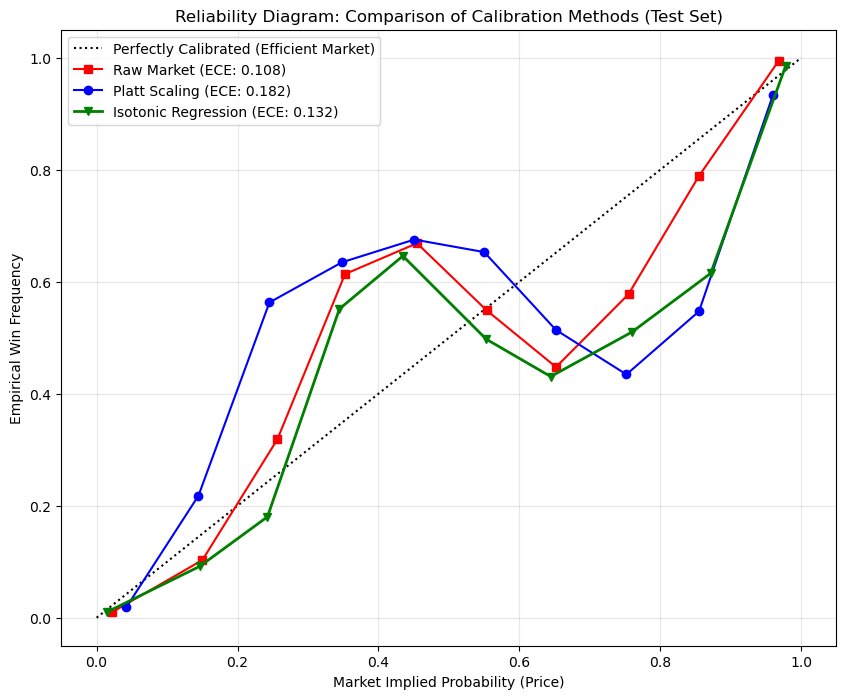

In [44]:
# Curves
prob_true_raw, prob_pred_raw = calibration_curve(y_test, p_raw_test, n_bins=10)
prob_true_platt, prob_pred_platt = calibration_curve(y_test, p_platt_test, n_bins=10)
prob_true_iso, prob_pred_iso = calibration_curve(y_test, p_iso_test, n_bins=10)

# Plotting
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated (Efficient Market)")

# Plot Raw Market
plt.plot(prob_pred_raw, prob_true_raw, "s-", label=f"Raw Market (ECE: {ece_raw:.3f})", color='red')

# Plot Platt Scaling
plt.plot(prob_pred_platt, prob_true_platt, "o-", label=f"Platt Scaling (ECE: {ece_platt:.3f})", color='blue')

# Plot Isotonic Regression
plt.plot(prob_pred_iso, prob_true_iso, "v-", label=f"Isotonic Regression (ECE: {ece_iso:.3f})", color='green', linewidth=2)

plt.xlabel("Market Implied Probability (Price)")
plt.ylabel("Empirical Win Frequency")
plt.title("Reliability Diagram: Comparison of Calibration Methods (Test Set)")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.savefig('../output/calibration_comparison_final.png')

In [45]:
# Feature Engineering
df_features = df_analysis.with_columns([
    # Time-to-Resolution (TTR)
    ((pl.col("end_date") - pl.col("timestamp")).dt.total_seconds() / 3600).alias("ttr_hours"),
    
    #  If volume is 0, set rel_size to 0 instead of inf
    pl.when(pl.col("volume") > 0)
      .then(pl.col("size") / pl.col("volume"))
      .otherwise(0)
      .alias("rel_size"),
    
    # use log1p(x) to avoid log(0) = -inf
    (pl.col("volume").log1p()).alias("log_volume")
])

print(df_features["category"].unique())
print(df_features["category"].value_counts())

# One-Hot Encode Categories (Politics, Crypto, etc.)， drop this as category as too many missing value
#df_features = df_features.to_dummies(columns=["category"])

# calculate volatility per market
vol_df = df_features.group_by("market_id").agg(
    pl.col("price").std().alias("market_volatility")
).fill_null(0)


# replaces any infinite value with 0
df_model = df_features.with_columns([
    pl.col("rel_size").replace([float('inf'), float('-inf')], 0),
    pl.col("log_volume").replace([float('inf'), float('-inf')], 0)
]).fill_null(0) 

df_model = df_features.join(vol_df, on="market_id", how="left")

shape: (1,)
Series: 'category' [str]
[
	""
]
shape: (1, 2)
┌──────────┬─────────┐
│ category ┆ count   │
│ ---      ┆ ---     │
│ str      ┆ u32     │
╞══════════╪═════════╡
│          ┆ 3962816 │
└──────────┴─────────┘


In [46]:
df_odds.head()

market_id,token_id,timestamp,price
str,str,datetime[μs],f64
"""248444""","""110809743739971564369615674270…",2023-01-24 00:00:12,0.04
"""248444""","""929887727274079089067923872273…",2023-01-24 00:00:12,0.97
"""248444""","""110809743739971564369615674270…",2023-01-25 00:00:14,0.03
"""248444""","""929887727274079089067923872273…",2023-01-25 00:00:14,0.98
"""248451""","""341647004688686334820900943006…",2023-01-25 00:00:14,0.03


In [47]:
# Sort both (Required for join_asof)
df_odds = df_odds.sort("timestamp")
df_analysis = df_analysis.sort("timestamp")

# Create History Features using Window Functions
df_odds_features = df_odds.with_columns([
    # Price Momentum: diff between current price and price x steps ago
    (pl.col("price") - pl.col("price").shift(5)).over("token_id").alias("mom_5"),
    (pl.col("price") - pl.col("price").shift(20)).over("token_id").alias("mom_20"),
    
    # Volatility: Rolling standard deviation
    pl.col("price").rolling_std(window_size=10).over("token_id").alias("hist_vol_10"),
    
    # Mean Reversion: Price vs Moving Average
    pl.col("price").rolling_mean(window_size=20).over("token_id").alias("ma_20")
]).with_columns([
    (pl.col("price") - pl.col("ma_20")).alias("dist_from_ma")
])

# Fill initial nulls (where window isn't full yet) with 0
df_odds_features = df_odds_features.fill_null(0)

In [48]:
df_model_final = df_model.join_asof(
    df_odds_features.select([
        "token_id", "timestamp", "mom_5", "mom_20", "hist_vol_10", "dist_from_ma"
    ]),
    on="timestamp",
    by="token_id",
    strategy="backward"
)

# Final cleanup
df_model_final = df_model_final.fill_null(0)

C:\Users\quant\AppData\Local\Temp\ipykernel_27268\3885206976.py:1: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_model_final = df_model.join_asof(


In [49]:
df_model_final.columns

['token_id',
 'market_id',
 'timestamp',
 'price',
 'size',
 'category',
 'volume',
 'closed',
 'end_date',
 'result',
 'ttr_hours',
 'rel_size',
 'log_volume',
 'market_volatility',
 'mom_5',
 'mom_20',
 'hist_vol_10',
 'dist_from_ma']

In [50]:
import xgboost as xgb
from sklearn.model_selection import GroupKFold,GridSearchCV
import random

# Select  features
feature_cols = ["price", "ttr_hours", "rel_size", "log_volume", "market_volatility","mom_5", "mom_20", "hist_vol_10", "dist_from_ma"] 
#feature_cols += [c for c in df_model_final.columns if c.startswith("category_")]

# Prepare X, y, and groups
X = df_model_final.select(feature_cols).with_columns([
    pl.col(pl.Float64).cast(pl.Float32) 
]).to_numpy()

y = df_model_final["result"].to_numpy().astype('int8') # Outcomes only need 1 byte
groups = df_model_final["market_id"].to_numpy()

random.seed(7406)
# save 20% of data post cv
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_val_idx, test_idx = next(gss.split(X, y, groups))

X_train_val, X_test = X[train_val_idx], X[test_idx]
y_train_val, y_test = y[train_val_idx], y[test_idx]
groups_train_val = groups[train_val_idx]

# GV tuning
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8]
}

# We set n_jobs=1 for memory efficiency
grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(objective="binary:logistic", random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=GroupKFold(n_splits=5),
    scoring='neg_brier_score',
    n_jobs=1, 
    verbose=2
)

print("Starting Grouped Tuning on Training/Validation markets...")
grid_search.fit(X_train_val, y_train_val, groups=groups_train_val)

# best model
best_xgb = grid_search.best_estimator_

# XGBoost Predictions
p_xgb = best_xgb.predict_proba(X_test)[:, 1]

# Isotonic Baseline (Only uses the 'price' column, which is index 0)
iso_reg = IsotonicRegression(out_of_bounds='clip')
iso_reg.fit(X_train_val[:, 0], y_train_val)
p_iso = iso_reg.transform(X_test[:, 0])

def print_metrics(name, y_true, y_prob):
    ece = calculate_ece(y_true, y_prob) # Assumes your ECE function is defined
    brier = brier_score_loss(y_true, y_prob)
    print(f"[{name}] ECE: {ece:.5f} | Brier: {brier:.5f}")

print("\n" + "="*30)
print("FINAL PERFORMANCE ON UNSEEN MARKETS")
print("="*30)
print(f"Best Params: {grid_search.best_params_}")
print_metrics("Isotonic Baseline", y_test, p_iso)
print_metrics("Optimized XGBoost", y_test, p_xgb)



Starting Grouped Tuning on Training/Validation markets...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END learning_rate=0.05, max_depth=3, n_estimators=100, subsample=0.8; total time=   8.6s
[CV] END learning_rate=0.05, max_depth=3, n_estimators=100, subsample=0.8; total time=   8.3s
[CV] END learning_rate=0.05, max_depth=3, n_estimators=100, subsample=0.8; total time=   7.9s
[CV] END learning_rate=0.05, max_depth=3, n_estimators=100, subsample=0.8; total time=   7.6s
[CV] END learning_rate=0.05, max_depth=3, n_estimators=100, subsample=0.8; total time=   7.3s
[CV] END learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.8; total time=  14.0s
[CV] END learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.8; total time=  13.8s
[CV] END learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.8; total time=  14.2s
[CV] END learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.8; total time=  14.8s
[CV] END learning_rate=0.05, max_de

In [51]:
# Metrics for Test Set
bs_iso = brier_score_loss(y_test, iso_model.transform(X_test[:, 0])) # Price only
bs_xgb = brier_score_loss(y_test, p_xgb) # Price + Context

ece_iso = calculate_ece(y_test, iso_model.transform(X_test[:, 0]))
ece_xgb = calculate_ece(y_test, p_xgb)

print(f"--- Final Comparison (Test Set) ---")
print(f"Isotonic Baseline -> Brier: {bs_iso:.5f}, ECE: {ece_iso:.5f}")
print(f"XGBoost Advanced  -> Brier: {bs_xgb:.5f}, ECE: {ece_xgb:.5f}")

--- Final Comparison (Test Set) ---
Isotonic Baseline -> Brier: 0.09462, ECE: 0.12970
XGBoost Advanced  -> Brier: 0.04884, ECE: 0.05377


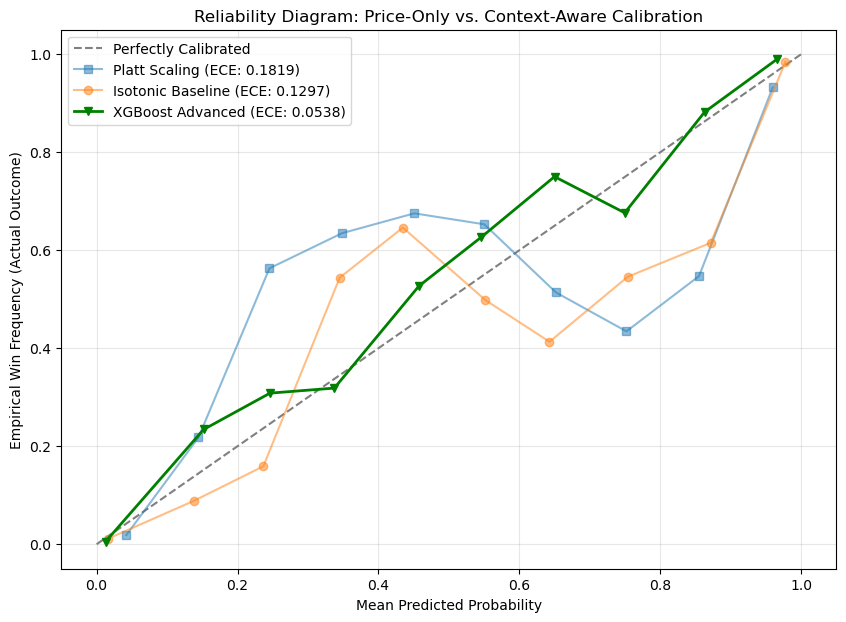

In [52]:
# Generate Platt Scaling probabilities for comparison
platt_model = LogisticRegression()
platt_model.fit(X_train_val[:, [0]], y_train_val) # Trained on price only
p_platt = platt_model.predict_proba(X_test[:, [0]])[:, 1]

# Calculate Calibration Curves (Binning)
iso_y, iso_x = calibration_curve(y_test, iso_model.transform(X_test[:, 0]), n_bins=10)
platt_y, platt_x = calibration_curve(y_test, p_platt, n_bins=10)
xgb_y, xgb_x = calibration_curve(y_test, p_xgb, n_bins=10)

plt.figure(figsize=(10, 7))

# The Perfect Calibration Line
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')

# Model Lines
plt.plot(platt_x, platt_y, marker='s', label=f'Platt Scaling (ECE: {ece_platt:.4f})', alpha=0.5)
plt.plot(iso_x, iso_y, marker='o', label=f'Isotonic Baseline (ECE: {ece_iso:.4f})', alpha=0.5)
plt.plot(xgb_x, xgb_y, marker='v', color='green', linewidth=2, label=f'XGBoost Advanced (ECE: {ece_xgb:.4f})')

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Empirical Win Frequency (Actual Outcome)')
plt.title('Reliability Diagram: Price-Only vs. Context-Aware Calibration')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.savefig('../output/calibration_comparison_final_xgboost.png')

In [53]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import SplineTransformer, StandardScaler

cont_features = ["price", "ttr_hours", "rel_size", "log_volume", "market_volatility","mom_5", "mom_20", "hist_vol_10", "dist_from_ma"]
# Map feature names to int in the numpy array
cont_indices = [i for i, col in enumerate(feature_cols) if col in cont_features]
cat_indices = [i for i, col in enumerate(feature_cols) if col.startswith("category_")]

print(f"Applying splines to {len(cont_indices)} features and passing through {len(cat_indices)} categories.")

# Build the Transformer with index
preprocessor = ColumnTransformer(
    transformers=[
        ('spline', SplineTransformer(n_knots=4, degree=3, knots='quantile'), cont_indices),
        ('pass', 'passthrough', cat_indices)
    ]
)

#logt regression pipeline
spline_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, solver='lbfgs', n_jobs=1))
])

#fitting
print("Training Spline-based Logistic Regression...")
spline_pipe.fit(X_train_val, y_train_val)

p_spline = spline_pipe.predict_proba(X_test)[:, 1]

#metrics
bs_spline = brier_score_loss(y_test, p_spline)
ece_spline = calculate_ece(y_test, p_spline)

print("\n--- Model Comparison (Test Set) ---")
print(f"XGBoost-> Brier: {bs_xgb:.5f}, ECE: {ece_xgb:.5f}") 
print(f"Spline Logistic Regression-> Brier: {bs_spline:.5f}, ECE: {ece_spline:.5f}")

Applying splines to 9 features and passing through 0 categories.
Training Spline-based Logistic Regression...

--- Model Comparison (Test Set) ---
XGBoost-> Brier: 0.04884, ECE: 0.05377
Spline Logistic Regression-> Brier: 0.05791, ECE: 0.09545


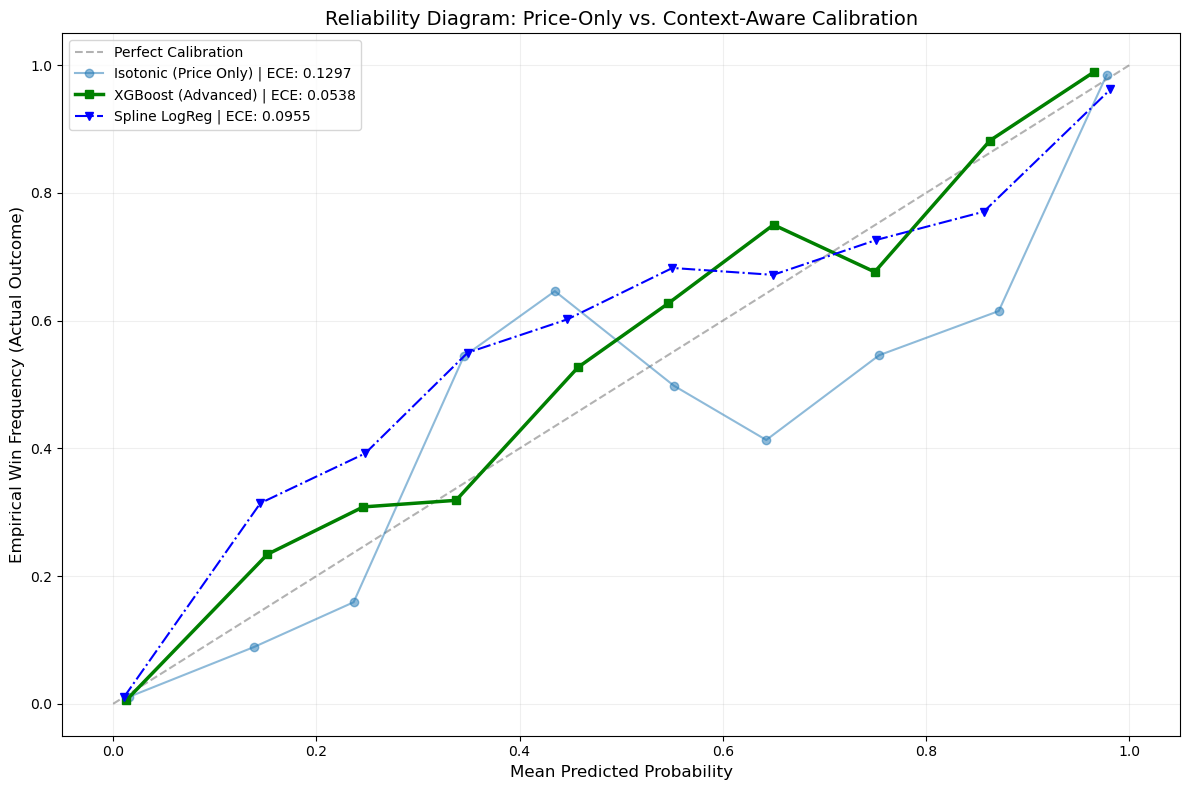

In [54]:
# Calculate calibration curves (10 bins is standard for 1M+ rows)
iso_y, iso_x = calibration_curve(y_test, iso_model.transform(X_test[:, 0]), n_bins=10)
xgb_y, xgb_x = calibration_curve(y_test, p_xgb, n_bins=10)
spline_y, spline_x = calibration_curve(y_test, p_spline, n_bins=10)

plt.figure(figsize=(12, 8))

# Perfectly Calibrated Reference Line
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfect Calibration', alpha=0.3)

# Model Lines
plt.plot(iso_x, iso_y, marker='o', label=f'Isotonic (Price Only) | ECE: {ece_iso:.4f}', alpha=0.5)
plt.plot(xgb_x, xgb_y, marker='s', color='green', linewidth=2.5, label=f'XGBoost (Advanced) | ECE: {ece_xgb:.4f}')
plt.plot(spline_x, spline_y, marker='v', color='blue', linestyle='-.', label=f'Spline LogReg | ECE: {ece_spline:.4f}')

# Formatting
plt.title('Reliability Diagram: Price-Only vs. Context-Aware Calibration', fontsize=14)
plt.xlabel('Mean Predicted Probability', fontsize=12)
plt.ylabel('Empirical Win Frequency (Actual Outcome)', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('../output/calibration_comparison_final_spline.png')

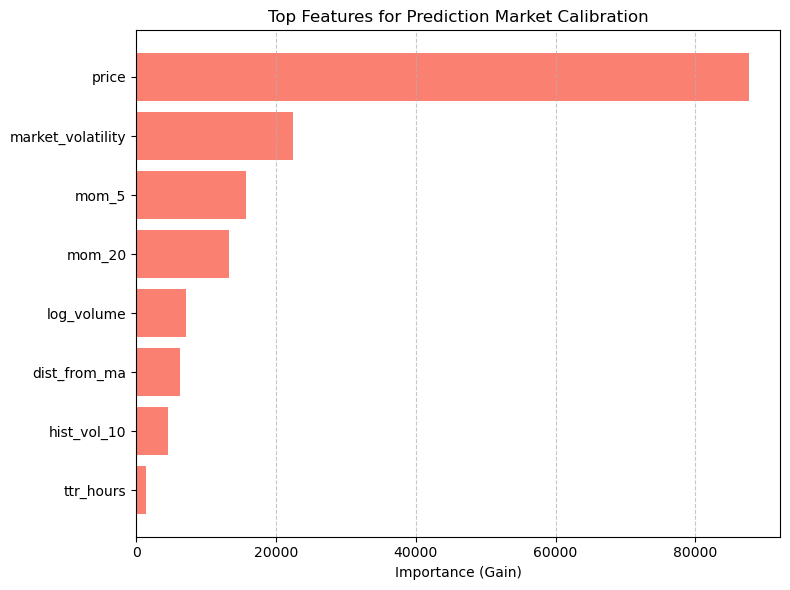

In [55]:
# 1. Extract importance scores (using 'gain')
# Note: if using the XGBClassifier wrapper, use .get_booster()
best_xgb_model= grid_search.best_estimator_
importance = best_xgb_model.get_booster().get_score(importance_type='gain')

# 2. Map the 'f0', 'f1' labels back to your actual feature names
# XGBoost names features f0, f1, etc. based on the index in X
feature_map = {f'f{i}': col for i, col in enumerate(feature_cols)}
importance_named = {feature_map[k]: v for k, v in importance.items()}

# 3. Create a DataFrame for easy plotting
df_importance = pd.DataFrame({
    'Feature': importance_named.keys(),
    'Importance': importance_named.values()
}).sort_values(by='Importance', ascending=True)

# 4. Plot the top 15 features
plt.figure(figsize=(8 , 6))
plt.barh(df_importance['Feature'].tail(15), df_importance['Importance'].tail(15), color='salmon')
plt.xlabel('Importance (Gain)')
plt.title('Top Features for Prediction Market Calibration')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()